shape : (4372, 123)
features utilisées pour le clustering : 40
['recency', 'frequency', 'monetarytotal', 'monetaryavg', 'monetarystd', 'avgquantitypertransaction', 'customertenuredays', 'firstpurchasedaysago', 'preferreddayofweek', 'preferredhour', 'preferredmonth', 'weekendpurchaseratio', 'avgdaysbetweenpurchases', 'uniqueproducts', 'avgproductspertransaction', 'uniquecountries', 'negativequantitycount', 'zeropricecount', 'returnratio', 'totaltransactions', 'uniqueinvoices', 'age', 'supportticketscount', 'satisfactionscore', 'regyear', 'regday', 'monetaryperday', 'avgbasketvalue', 'purchaseintensity', 'tenureratio', 'productdiversityratio', 'returnimpact', 'customerscorenormalized', 'monetaryperday_log', 'avgbasketvalue_log', 'returnimpact_log', 'regmonth_sin', 'regmonth_cos', 'regweekday_sin', 'regweekday_cos']
clients avant suppression outliers : 4372
clients après suppression outliers : 3987
outliers supprimés : 385
données normalisées — shape : (3987, 40)
composantes PCA retenues 

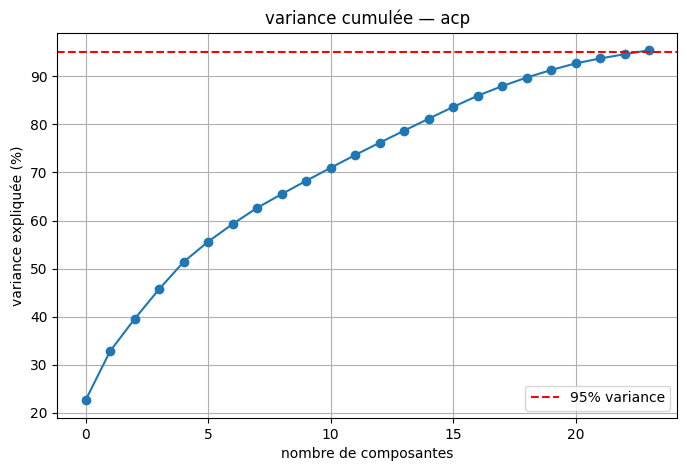

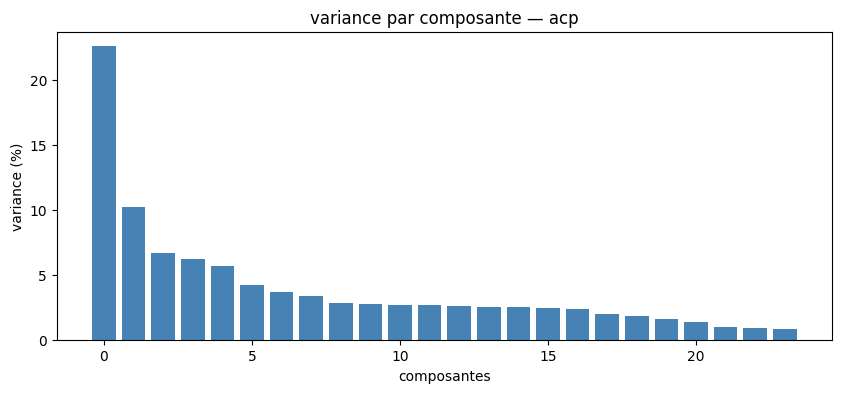

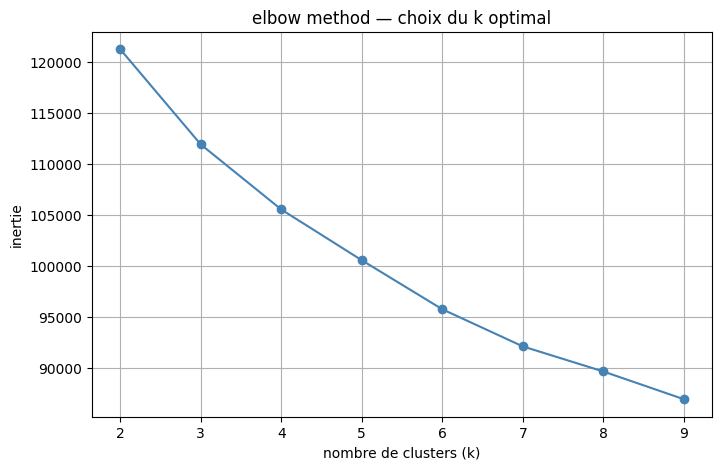

→ choisir le k au niveau du 'coude' de la courbe
distribution des clusters :
cluster
0     695
1    1122
2     743
3    1427
Name: count, dtype: int64


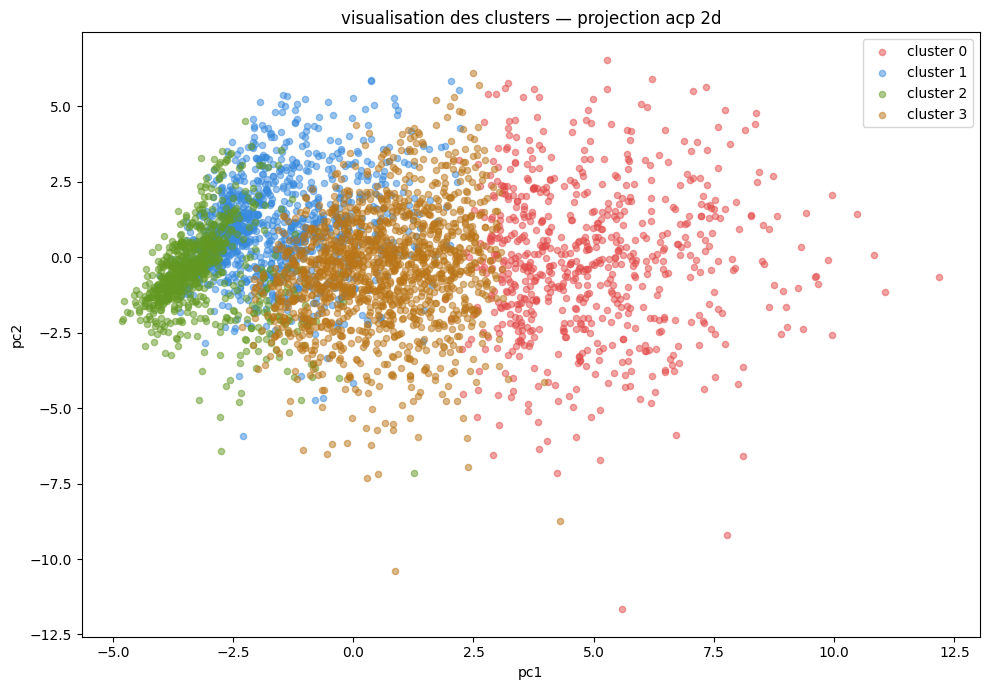


=== profils des clusters ===
         recency  frequency  monetarytotal  churn  nb_clients  pct_clients
cluster                                                                   
0           26.2        8.9         2754.0    0.1         695         17.4
1           49.5        1.7          481.5    0.1        1122         28.1
2          259.5        1.2          276.4    1.0         743         18.6
3           73.0        4.1         1015.8    0.3        1427         35.8


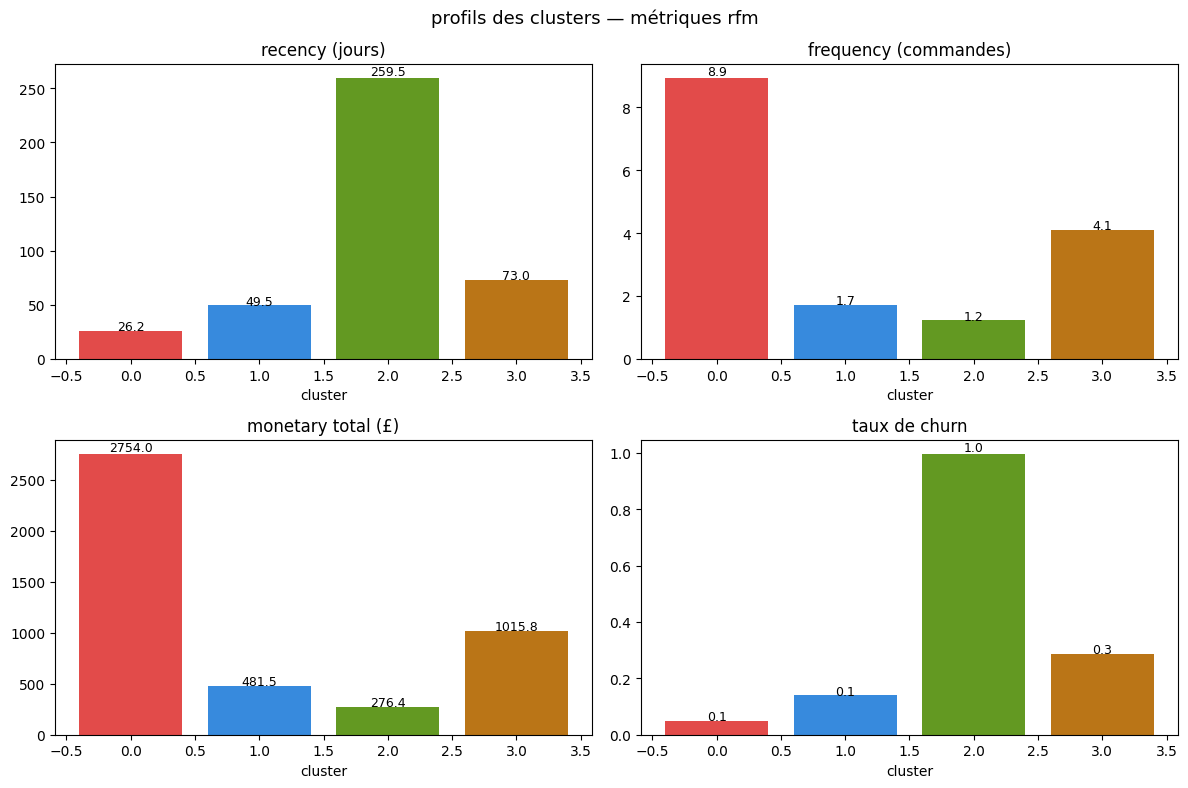

distribution des segments :
segment
clients réguliers    1427
clients champions    1122
clients à risque      743
clients perdus        695
Name: count, dtype: int64

=== tableau récapitulatif des segments ===
                   nb_clients  recency_moy  frequency_moy  monetary_moy  churn_taux   pct
segment                                                                                  
clients champions        1122         49.5            1.7         481.5        10.0  28.1
clients perdus            695         26.2            8.9        2754.0        10.0  17.4
clients réguliers        1427         73.0            4.1        1015.8        30.0  35.8
clients à risque          743        259.5            1.2         276.4       100.0  18.6

=== recommandations marketing ===

  [clients perdus] — 695 clients — churn 10.0%
  → campagne de réactivation urgente ou abandon du segment

  [clients champions] — 1122 clients — churn 10.0%
  → programme vip, récompenses fidélité, offres exclusiv

KeyError: "None of [Index(['recency', 'frequency', 'monetarytotal', 'churn'], dtype='str')] are in the [columns]"

In [2]:
# %% [markdown]
# # étape 4 — clustering k-means
# lit     : data/processed/step3_feature_engineering.csv
# produit : data/processed/step4_clustering.csv

# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from scipy.stats import zscore

# %%
df = pd.read_csv('../data/processed/step3_feature_engineering.csv')

print("shape :", df.shape)
df.head()

# %% [markdown]
# # 1. préparation des données pour le clustering

# %% [markdown]
# 1.1 sélection des features numériques (hors target)

# %%
# on garde uniquement les colonnes numériques pour le clustering
# on exclut churn (target) et les colonnes binaires one-hot
exclude = ['churn']

num_cols = [c for c in df.select_dtypes(include=['int64','float64']).columns
            if c not in exclude]

print(f"features utilisées pour le clustering : {len(num_cols)}")
print(num_cols)

# %% [markdown]
# 1.2 suppression des outliers extrêmes (z-score > 4)

# %%
df_clust = df.copy()

# calculer z-score sur les features numériques
z_scores = np.abs(zscore(df_clust[num_cols], nan_policy='omit'))

# garder seulement les lignes sans outlier extrême
mask = (z_scores < 4).all(axis=1)
df_clust = df_clust[mask].reset_index(drop=True)

print(f"clients avant suppression outliers : {len(df)}")
print(f"clients après suppression outliers : {len(df_clust)}")
print(f"outliers supprimés : {len(df) - len(df_clust)}")

# %% [markdown]
# 1.3 normalisation (StandardScaler)

# %%
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clust[num_cols])

print("données normalisées — shape :", X_scaled.shape)

# %% [markdown]
# # 2. réduction de dimension — ACP

# %%
# garder 95% de la variance
pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"composantes PCA retenues : {pca.n_components_}")
print(f"variance expliquée totale : {pca.explained_variance_ratio_.sum()*100:.1f}%")

# %%
# variance cumulée
plt.figure(figsize=(8,5))
plt.plot(np.cumsum(pca.explained_variance_ratio_)*100, marker='o')
plt.axhline(95, color='red', linestyle='--', label='95% variance')
plt.title("variance cumulée — acp")
plt.xlabel("nombre de composantes")
plt.ylabel("variance expliquée (%)")
plt.legend()
plt.grid()
plt.show()

# %%
# variance par composante
plt.figure(figsize=(10,4))
plt.bar(range(len(pca.explained_variance_ratio_)),
        pca.explained_variance_ratio_ * 100,
        color='steelblue')
plt.title("variance par composante — acp")
plt.xlabel("composantes")
plt.ylabel("variance (%)")
plt.show()

# %% [markdown]
# # 3. elbow method — trouver le k optimal

# %%
inertia = []
k_range = range(2, 10)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_pca)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(k_range, inertia, marker='o', color='steelblue')
plt.title("elbow method — choix du k optimal")
plt.xlabel("nombre de clusters (k)")
plt.ylabel("inertie")
plt.grid()
plt.show()

print("→ choisir le k au niveau du 'coude' de la courbe")

# %% [markdown]
# # 4. k-means avec k=4

# %%
k_optimal = 4

kmeans = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
df_clust['cluster'] = kmeans.fit_predict(X_pca)

print("distribution des clusters :")
print(df_clust['cluster'].value_counts().sort_index())

# %% [markdown]
# # 5. visualisation 2d des clusters (acp)

# %%
pca_2d = PCA(n_components=2, random_state=42)
X_2d = pca_2d.fit_transform(X_scaled)

plt.figure(figsize=(10,7))
colors = ['#E24B4A', '#378ADD', '#639922', '#BA7517']
for i in range(k_optimal):
    mask_c = df_clust['cluster'] == i
    plt.scatter(X_2d[mask_c, 0], X_2d[mask_c, 1],
                c=colors[i], label=f'cluster {i}',
                alpha=0.5, s=20)

plt.title("visualisation des clusters — projection acp 2d")
plt.xlabel("pc1")
plt.ylabel("pc2")
plt.legend()
plt.tight_layout()
plt.show()

# %% [markdown]
# # 6. profils des clusters (rfm)

# %%
# features clés pour interpréter les clusters
rfm_cols = ['recency', 'frequency', 'monetarytotal', 'churn']
rfm_cols = [c for c in rfm_cols if c in df_clust.columns]

cluster_profiles = df_clust.groupby('cluster')[rfm_cols].mean().round(1)
cluster_profiles['nb_clients'] = df_clust['cluster'].value_counts().sort_index()
cluster_profiles['pct_clients'] = (
    cluster_profiles['nb_clients'] / len(df_clust) * 100
).round(1)

print("\n=== profils des clusters ===")
print(cluster_profiles)

# %%
# visualisation des profils
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

metrics = ['recency', 'frequency', 'monetarytotal', 'churn']
titles  = ['recency (jours)', 'frequency (commandes)',
           'monetary total (£)', 'taux de churn']

for ax, metric, title in zip(axes.flatten(), metrics, titles):
    if metric in df_clust.columns:
        vals = df_clust.groupby('cluster')[metric].mean()
        bars = ax.bar(range(k_optimal), vals, color=colors)
        ax.set_title(title)
        ax.set_xlabel("cluster")
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() * 1.01,
                    f"{val:.1f}", ha='center', fontsize=9)

plt.suptitle("profils des clusters — métriques rfm", fontsize=13)
plt.tight_layout()
plt.show()

# %% [markdown]
# # 7. nommage des segments

# %% [markdown]
# analyser cluster_profiles pour nommer les segments :
# - recency élevée + frequency faible + churn élevé  → "clients perdus"
# - recency faible + frequency élevée + churn faible → "clients champions"
# - recency moyenne + churn moyen                    → "clients à risque"
# - recency faible + frequency faible + churn faible → "clients réguliers"

# %%
# nommer selon les profils observés
# ⚠️ adapter selon tes résultats réels

segment_names = {
    0: 'clients perdus',
    1: 'clients champions',
    2: 'clients à risque',
    3: 'clients réguliers',
}

df_clust['segment'] = df_clust['cluster'].map(segment_names)

print("distribution des segments :")
print(df_clust['segment'].value_counts())

# %%
# tableau récapitulatif complet
summary = df_clust.groupby('segment').agg(
    nb_clients   = ('cluster', 'count'),
    recency_moy  = ('recency', 'mean'),
    frequency_moy= ('frequency', 'mean'),
    monetary_moy = ('monetarytotal', 'mean'),
    churn_taux   = ('churn', 'mean'),
).round(1)

summary['pct'] = (summary['nb_clients'] / len(df_clust) * 100).round(1)
summary['churn_taux'] = (summary['churn_taux'] * 100).round(1)

print("\n=== tableau récapitulatif des segments ===")
print(summary.to_string())

# %% [markdown]
# # 8. recommandations marketing par segment

# %%
recommandations = {
    'clients perdus'    : 'campagne de réactivation urgente ou abandon du segment',
    'clients champions' : 'programme vip, récompenses fidélité, offres exclusives',
    'clients à risque'  : 'promotions personnalisées, offres spéciales urgentes',
    'clients réguliers' : 'newsletter, encourager augmentation de la fréquence',
}

print("\n=== recommandations marketing ===")
for seg, rec in recommandations.items():
    n = summary.loc[seg, 'nb_clients'] if seg in summary.index else '?'
    c = summary.loc[seg, 'churn_taux'] if seg in summary.index else '?'
    print(f"\n  [{seg}] — {n} clients — churn {c}%")
    print(f"  → {rec}")

# %% [markdown]
# # 9. heatmap des profils normalisés

# %%
# normaliser pour comparer les segments sur la même échelle
from sklearn.preprocessing import MinMaxScaler

profile_cols = [c for c in ['recency','frequency','monetarytotal','churn']
                if c in df_clust.columns]

profile_norm = summary[profile_cols].copy()
mms = MinMaxScaler()
profile_norm[profile_cols] = mms.fit_transform(profile_norm[profile_cols])

plt.figure(figsize=(8,5))
sns.heatmap(profile_norm,
            annot=summary[profile_cols].round(1),
            fmt='g',
            cmap='YlOrRd',
            linewidths=0.5)
plt.title("heatmap des profils segments (normalisés)")
plt.tight_layout()
plt.show()

# %% [markdown]
# # 10. sauvegarde

# %%
df_clust.to_csv('../data/processed/step4_clustering.csv', index=False)
print(f"\n✅ sauvegardé : data/processed/step4_clustering.csv")
print(f"   {len(df_clust)} clients — {k_optimal} clusters")
print(f"   colonnes ajoutées : cluster, segment")